# **End-to-End Credit Risk Modeling - Lending Club Loan Portfolio Analysis**

Author: Salsabila Eka Hariadi  
Field: Data Analytics | Credit Risk | Financial Analytics

---

## Business Background

Credit risk assessment is a critical function for financial institutions such as banks, fintech companies, and digital lending platforms.

Before issuing a loan, lenders must evaluate the likelihood that a borrower will successfully repay the loan. Inaccurate credit risk assessment may lead to elevated default rates, which can significantly impact financial performance and portfolio stability.

To mitigate these risks, financial institutions increasingly rely on **data analytics and machine learning** to evaluate borrower characteristics, financial behavior, and historical repayment patterns. These analytical approaches enable lenders to make more informed credit decisions and optimize risk management strategies.

---

## Project Objective

This project analyzes borrower data from the Lending Club loan portfolio to identify patterns associated with loan performance and borrower risk.

The primary objectives of this analysis are to:

* Understand the structure of the loan portfolio
* Examine borrower financial characteristics
* Identify factors associated with loan default behavior
* Develop a predictive model for credit risk assessment
* Generate insights that support data-driven lending decisions


---

## Analytical Workflow

This project follows a structured data analytics pipeline:

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Credit Risk Modeling (Logistic Regression & XGBoost)
6. Model Evaluation (ROC, AUC, KS Statistic)
7. Risk Segmentation and Business Insights
8. Model Explainability (SHAP Analysis)
9. Portfolio Risk Dashboard
10. Expected Loss Simulation (PD × LGD × EAD)

This notebook focuses on the **initial stages of the analysis**, which are data preparation and exploratory analysis.

# **Dataset Description**

The dataset used in this analysis contains borrower information and loan characteristics from Lending Club, a peer-to-peer lending platform.

Each observation represents a single loan issued to an individual borrower.

The dataset includes information about loan characteristics, borrower financial profiles, and credit history indicators.

---

## Key Variables

### Loan Characteristics

loan_amnt  
Amount of the loan requested by the borrower.

term  
Loan duration in months.

int_rate  
Interest rate assigned to the loan.

installment  
Monthly payment amount for the loan.

---

### Borrower Financial Profile

annual_inc  
Annual income reported by the borrower.

dti  
Debt-to-income ratio.

emp_length  
Length of employment.

home_ownership  
Home ownership status.

---

### Credit History Indicators

open_acc  
Number of open credit accounts.

total_acc  
Total number of credit accounts.

revol_bal  
Total revolving credit balance.

revol_util  
Credit utilization ratio.

---

### Loan Outcome

loan_status  
Repayment status of the loan (e.g., Fully Paid, Charged Off).

This variable is important because it indicates **loan performance**.

# **Data Loading**

The dataset is imported from an Excel file and inspected to understand its structure and contents.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_excel("/content/lending_club.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (396029, 20)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,1000,36 months,13.67,34.02,B,B5,< 1 year,RENT,50000,Source Verified,Fully Paid,debt_consolidation,13.58,15.0,0.0,6431.0,33.5,19.0,0,0.0
1,1000,36 months,10.99,32.74,B,B3,10+ years,OWN,60000,Not Verified,Fully Paid,debt_consolidation,14.76,6.0,0.0,22939.0,95.6,24.0,NaN,0.0
2,1000,36 months,7.39,31.06,A,A4,4 years,RENT,55000,Source Verified,Fully Paid,other,16.17,10.0,0.0,9079.0,33.5,12.0,0,0.0
3,1000,36 months,15.31,34.82,C,C5,1 year,RENT,75000,Not Verified,Fully Paid,other,8.91,8.0,0.0,10765.0,94.0,11.0,0,0.0
4,1000,36 months,12.59,33.50,C,C2,3 years,RENT,43500,Source Verified,Fully Paid,credit_card,22.57,21.0,1.0,3069.0,6.5,36.0,1,1.0


In [2]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396029 entries, 0 to 396028
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396029 non-null  int64  
 1   term                  396029 non-null  object 
 2   int_rate              396029 non-null  float64
 3   installment           396029 non-null  float64
 4   grade                 396029 non-null  object 
 5   sub_grade             396029 non-null  object 
 6   emp_length            377684 non-null  object 
 7   home_ownership        395985 non-null  object 
 8   annual_inc            395985 non-null  object 
 9   verification_status   395985 non-null  object 
 10  loan_status           395985 non-null  object 
 11  purpose               395985 non-null  object 
 12  dti                   395952 non-null  object 
 13  open_acc              395953 non-null  float64
 14  pub_rec               395953 non-null  float64
 15  

,count,mean,std,min,25%,50%,75%,max
loan_amnt,396029.0,14113.898540,8357.449305,500.00,8000.00,12000.00,20000.00,40000.00
int_rate,396029.0,13.639415,4.472153,5.32,10.49,13.33,16.49,30.99
installment,396029.0,431.850004,250.728032,16.08,250.33,375.43,567.30,1533.81
open_acc,395953.0,12.312797,190.499126,0.00,8.00,10.00,14.00,39753.00
pub_rec,395953.0,0.178473,0.533860,0.00,0.00,0.00,0.00,86.00
revol_bal,395953.0,15844.209035,20593.064312,0.00,6025.00,11181.00,19619.00,1743266.00
revol_util,395677.0,54.141990,101.911327,0.00,35.80,54.80,72.90,51427.00
total_acc,395953.0,25.415383,11.887877,2.00,17.00,24.00,32.00,151.00
pub_rec_bankruptcies,395418.0,0.121681,0.356308,0.00,0.00,0.00,0.00,8.00


# **Data Cleaning**

Before performing analysis, the dataset must be cleaned to ensure data quality and consistency.

The cleaning process includes:

• correcting data types  
• handling missing values  
• preparing variables for analysis

In [3]:
df.columns = df.columns.str.lower().str.strip()

In [4]:
df["term"] = df["term"].str.replace(" months","").astype(int)

In [5]:
if df["term"].dtype == "object":
    df["term"] = df["term"].str.replace(" months","").astype(int)

In [6]:
numeric_cols = [
    "annual_inc",
    "dti",
    "mort_acc"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [7]:
num_cols = [
    "annual_inc",
    "dti",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc"
]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [8]:
cat_cols = [
    "home_ownership",
    "verification_status",
    "loan_status",
    "purpose"
]

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

# **Exploratory Data Analysis (EDA)**

This section explores the structure, distribution, and financial behavior patterns within the Lending Club loan portfolio.

The goal of this analysis is to understand:

• Borrower characteristics  
• Loan portfolio structure  
• Credit risk patterns  
• Default behavior  

These insights will guide the **feature engineering and credit risk modeling** stages.

From a business perspective, this section simulates how a **risk analyst at a financial institution evaluates borrower risk and portfolio exposure.**

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

## Loan Portfolio Overview

We begin by examining the overall structure of the lending portfolio.

Key questions explored:

• What is the distribution of loan amounts?  
• How are interest rates distributed?  
• What loan terms dominate the portfolio?

Understanding these characteristics helps identify **portfolio concentration and lending strategy patterns**.

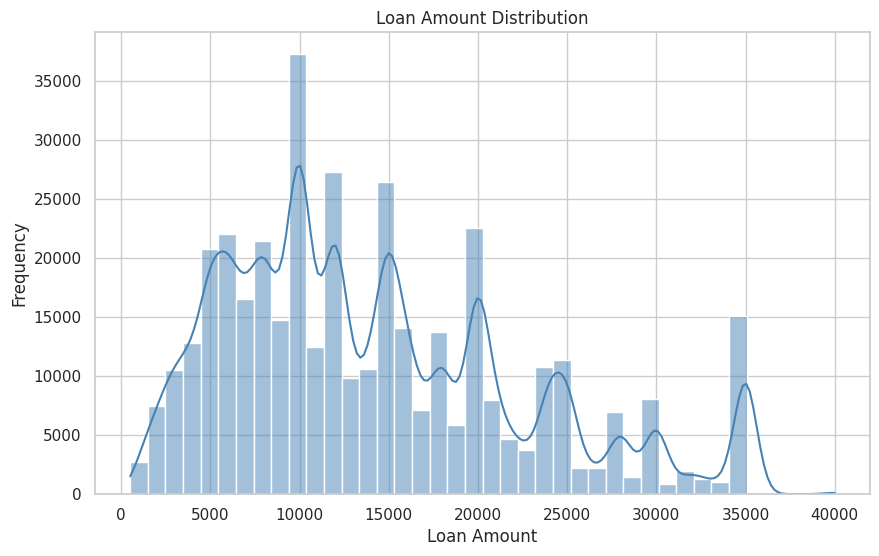

In [10]:
plt.figure()

sns.histplot(
    df["loan_amnt"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

The loan amount distribution is right-skewed, indicating that most loans fall within the small to medium loan range, while very large loans occur less frequently.

This suggests that the Lending Club portfolio primarily consists of retail consumer loans rather than large institutional lending. A diversified distribution of loan sizes reduces concentration risk but may still lead to significant aggregate losses if default rates rise across many borrowers.

From a risk management perspective, understanding loan size distribution is important because larger loan exposures can generate higher financial losses in the event of borrower default.

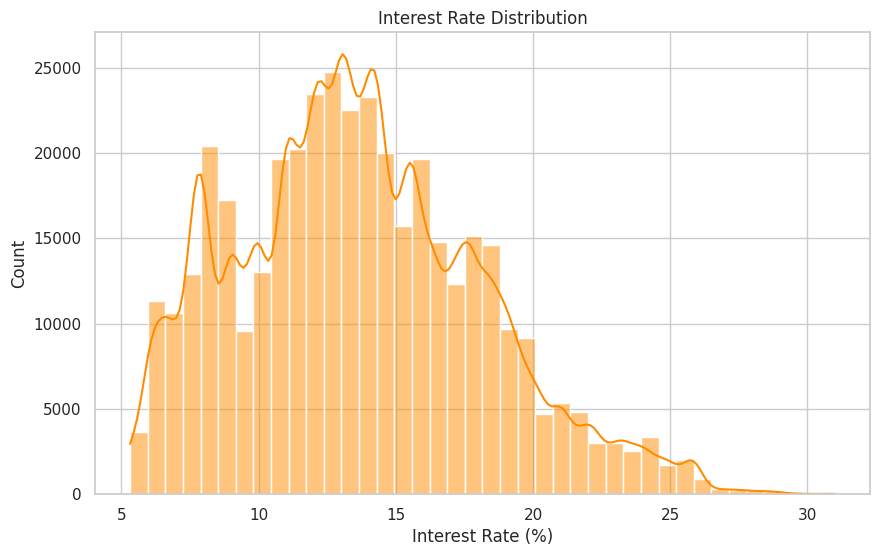

In [11]:
plt.figure()

sns.histplot(
    df["int_rate"],
    bins=40,
    kde=True,
    color="darkorange"
)

plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate (%)")

plt.show()

/tmp/ipykernel_198/2581471110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


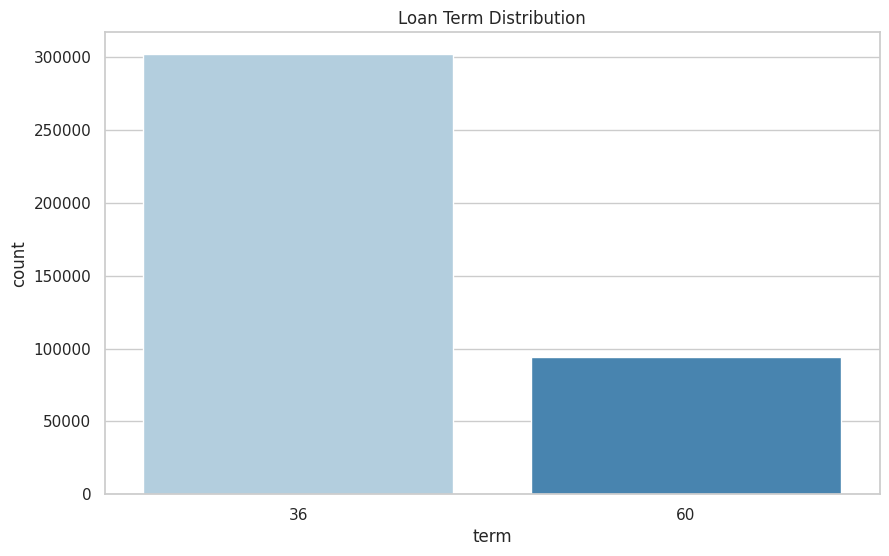

In [12]:
plt.figure()

sns.countplot(
    x="term",
    data=df,
    palette="Blues"
)

plt.title("Loan Term Distribution")

plt.show()

The loan term distribution shows that the majority of loans are issued with either 36-month or 60-month repayment periods.

Longer loan terms increase the exposure period for lenders, which may raise the probability of default as borrowers face a longer horizon of financial uncertainty.

In credit risk management, longer-term loans typically require stronger borrower screening and risk-adjusted interest rates to compensate for the increased risk exposure.

## Borrower Characteristics

Next, we analyze key borrower financial attributes that are commonly used in **credit underwriting and risk scoring models**.

Variables explored:

• Borrower annual income  
• Debt-to-Income ratio (DTI)  
• Revolving credit utilization  

These indicators provide insight into **borrower repayment capacity and credit behavior**.

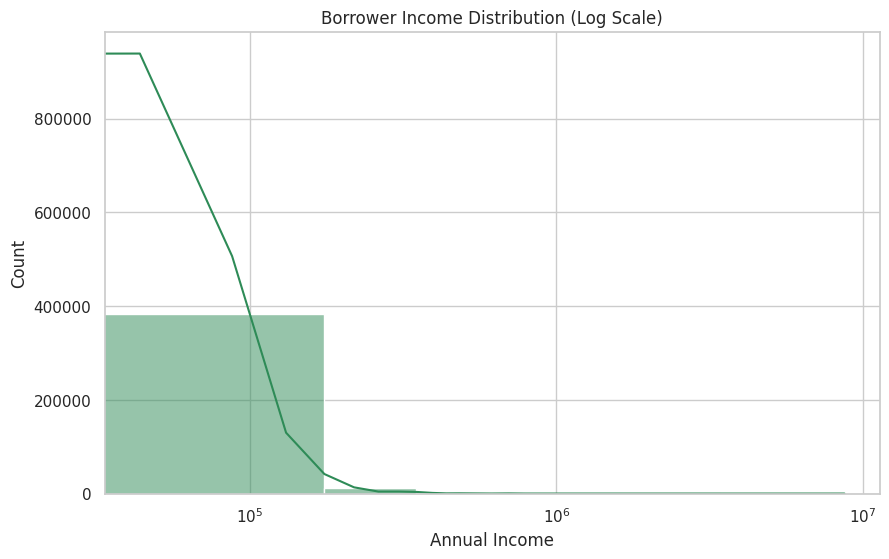

In [13]:
plt.figure()

sns.histplot(
    df["annual_inc"],
    bins=50,
    kde=True,
    color="seagreen"
)

plt.xscale("log")

plt.title("Borrower Income Distribution (Log Scale)")
plt.xlabel("Annual Income")

plt.show()

The borrower income distribution is highly right-skewed, with most borrowers falling within the lower to middle income ranges, while a smaller portion of borrowers report significantly higher income levels.

The average borrower income in the dataset is approximately $74,201, indicating that the lending platform primarily serves middle-income individuals.

Higher income borrowers generally demonstrate stronger repayment capacity, whereas lower income segments may face higher vulnerability to financial stress and default risk.

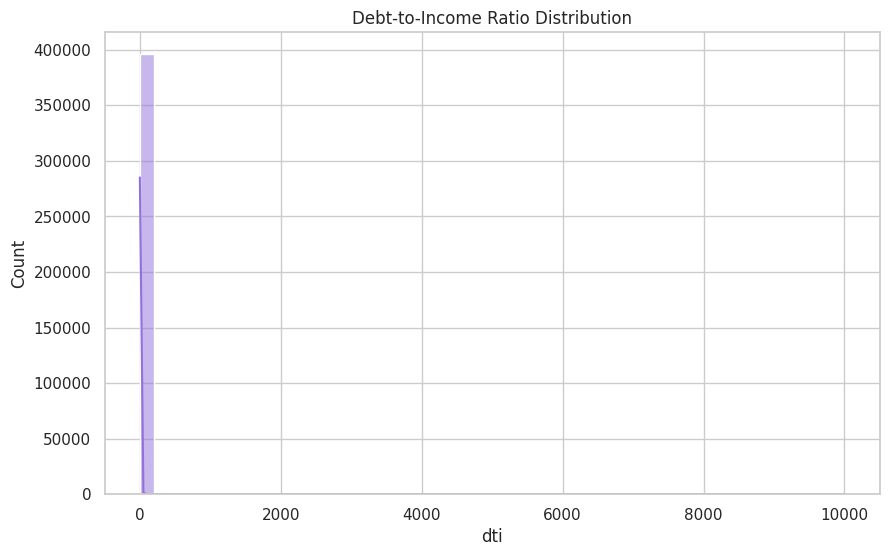

In [14]:
plt.figure()

sns.histplot(
    df["dti"],
    bins=50,
    kde=True,
    color="mediumpurple"
)

plt.title("Debt-to-Income Ratio Distribution")

plt.show()

The Debt-to-Income (DTI) distribution shows that most borrowers maintain moderate leverage levels, with an average DTI of approximately 17.38.

DTI represents the proportion of a borrower's income allocated to debt obligations. Higher DTI values indicate that a larger share of income is already committed to debt payments.

Borrowers with elevated DTI ratios are generally more vulnerable to financial shocks and are more likely to experience repayment difficulties, making DTI a key indicator in credit risk assessment.

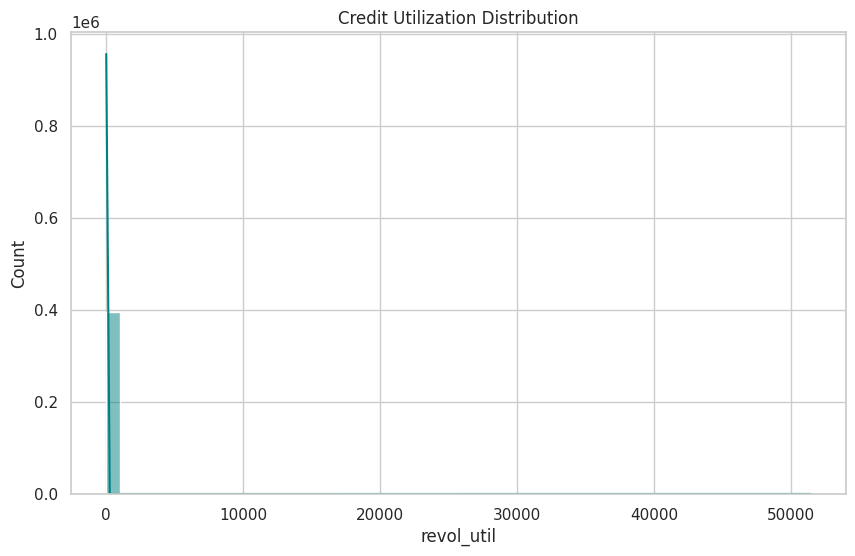

In [15]:
plt.figure()

sns.histplot(
    df["revol_util"],
    bins=50,
    kde=True,
    color="teal"
)

plt.title("Credit Utilization Distribution")

plt.show()

Credit utilization reflects the percentage of available revolving credit currently being used by borrowers.

The distribution indicates that many borrowers operate within moderate utilization levels, while a segment of borrowers exhibits high credit utilization.

High credit utilization often signals financial stress and reduced borrowing capacity, making it an important predictor of potential default behavior in credit risk models.

## Loan Outcome Analysis

Loan status indicates the repayment outcome of each loan issued.

By analyzing loan outcomes, we obtain an initial understanding of:

• Portfolio repayment performance  
• Overall default proportion

/tmp/ipykernel_198/978161992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


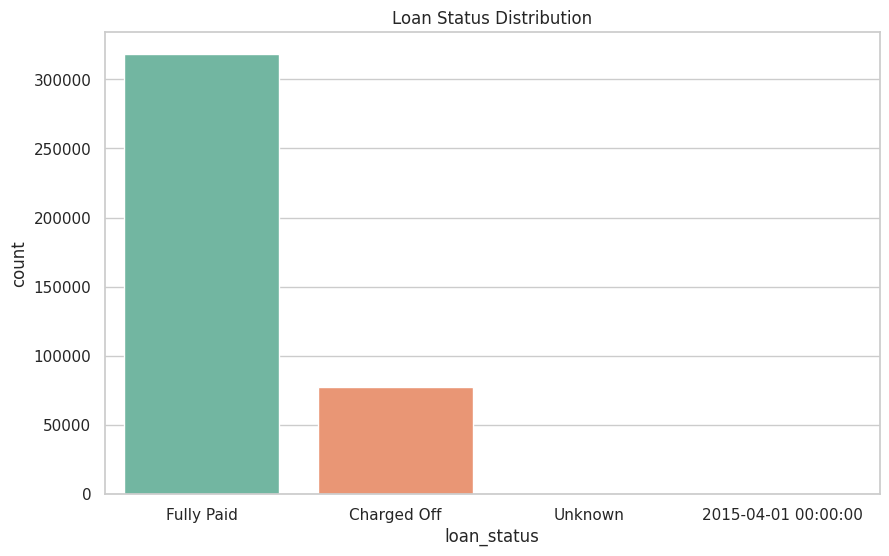

In [16]:
plt.figure()

sns.countplot(
    x="loan_status",
    data=df,
    palette="Set2"
)

plt.title("Loan Status Distribution")

plt.show()

The loan status distribution shows that the majority of loans are fully repaid, while a significant portion of loans end in default (Charged Off).

The portfolio exhibits an overall default rate of approximately 19.6%, indicating that nearly one out of five loans experiences default.

This highlights the importance of effective credit risk modeling and borrower screening to reduce financial losses and maintain portfolio stability.

## Credit Risk Behavior

This section examines how borrower financial characteristics differ between:

• Performing loans (Fully Paid)  
• Defaulted loans (Charged Off)

Understanding these differences helps identify **key drivers of credit risk**.

/tmp/ipykernel_198/1442341950.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


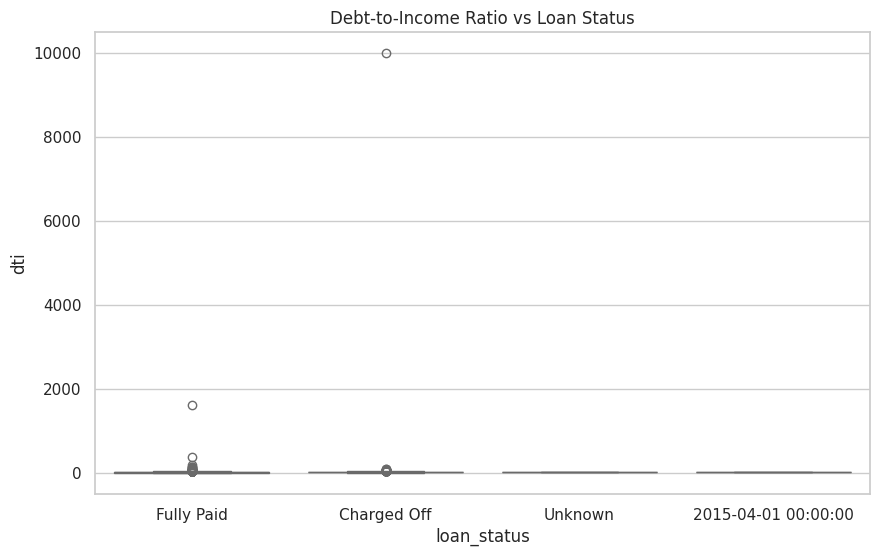

In [17]:
plt.figure()

sns.boxplot(
    x="loan_status",
    y="dti",
    data=df,
    palette="Set3"
)

plt.title("Debt-to-Income Ratio vs Loan Status")

plt.show()

The boxplot comparing Debt-to-Income ratios across loan outcomes shows that borrowers who defaulted tend to have higher DTI levels compared to borrowers who fully repaid their loans.

This indicates that borrowers with greater financial leverage are more likely to experience repayment difficulties.

The result reinforces the importance of DTI as a key predictor of credit risk and an essential variable in credit underwriting models.

/tmp/ipykernel_198/1522211929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


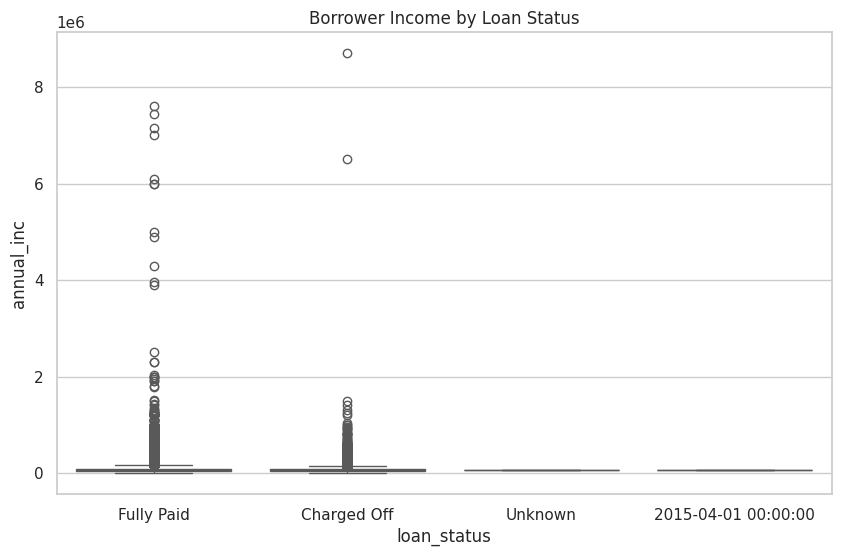

In [18]:
plt.figure()

sns.boxplot(
    x="loan_status",
    y="annual_inc",
    data=df,
    palette="Set2"
)

plt.title("Borrower Income by Loan Status")

plt.show()

Borrowers who successfully repaid their loans generally exhibit higher average income levels compared to those who defaulted.

Higher income provides greater financial resilience and repayment capacity, reducing the likelihood of loan default.

This pattern suggests that income-based borrower segmentation may improve lending decisions and credit risk management strategies.

/tmp/ipykernel_198/3110136196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


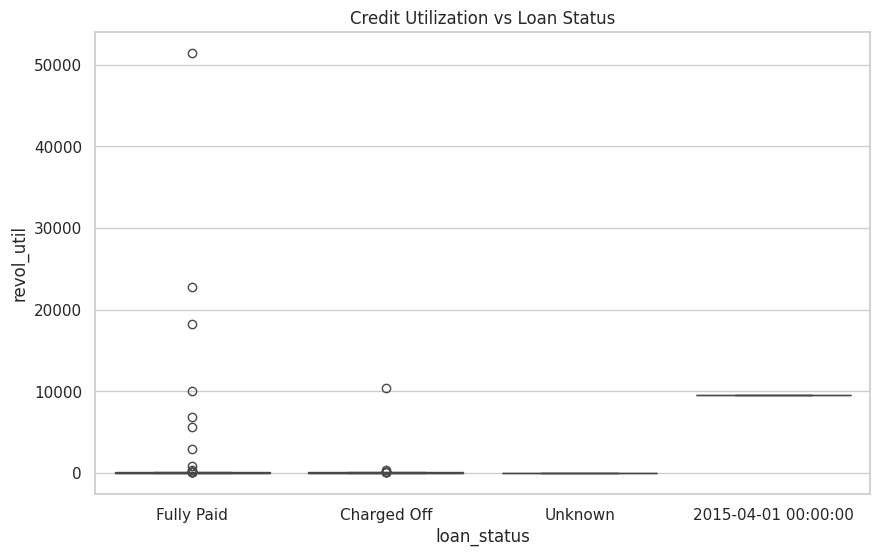

In [19]:
plt.figure()

sns.boxplot(
    x="loan_status",
    y="revol_util",
    data=df,
    palette="Set1"
)

plt.title("Credit Utilization vs Loan Status")

plt.show()

The comparison between credit utilization and loan status indicates that borrowers who defaulted tend to have higher average credit utilization ratios.

High credit utilization suggests that borrowers are already using a large portion of their available credit, which may indicate financial pressure or limited liquidity.

As a result, credit utilization serves as a strong behavioral indicator of elevated credit risk.

## Default Rate by Credit Grade

Credit grades represent internal borrower risk ratings.

Higher grades correspond to **lower credit risk**, while lower grades represent **higher default risk**.

Analyzing default rates across grades allows us to evaluate whether **risk differentiation is reflected in actual loan outcomes**.

In [20]:
default_rate = pd.crosstab(
    df["grade"],
    df["loan_status"],
    normalize="index"
)

default_rate

loan_status,2015-04-01 00:00:00,Charged Off,Fully Paid,Unknown
grade,,,,
A,0.000000,0.062864,0.937042,0.000093
B,0.000000,0.125722,0.874157,0.000121
C,0.000009,0.211762,0.788116,0.000113
D,0.000000,0.288647,0.711243,0.000110
E,0.000000,0.373571,0.626302,0.000127
F,0.000000,0.427880,0.572035,0.000085
G,0.000000,0.478389,0.521611,0.000000


The default rate increases consistently as credit grades decline from Grade A to Grade G.

Borrowers with higher credit grades (A–B) exhibit significantly lower default rates, while lower grades (E–G) show substantially higher default probabilities.

This pattern confirms that the credit grading system effectively differentiates borrower risk levels and aligns with observed loan performance outcomes.

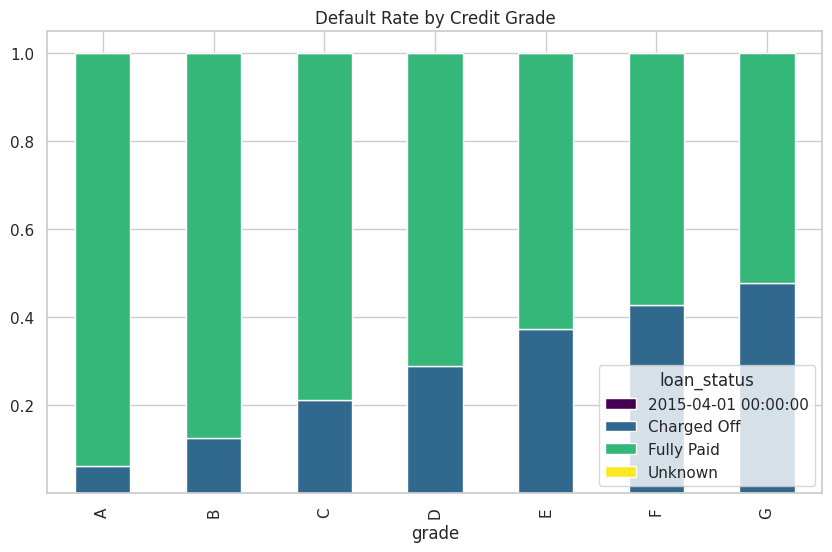

In [21]:
default_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="viridis"
)

plt.title("Default Rate by Credit Grade")

plt.show()

## Default Rate Heatmap

This heatmap visualizes default probability across two important credit dimensions:

• Credit grade  
• Loan term

It allows quick identification of **high-risk segments within the loan portfolio**.

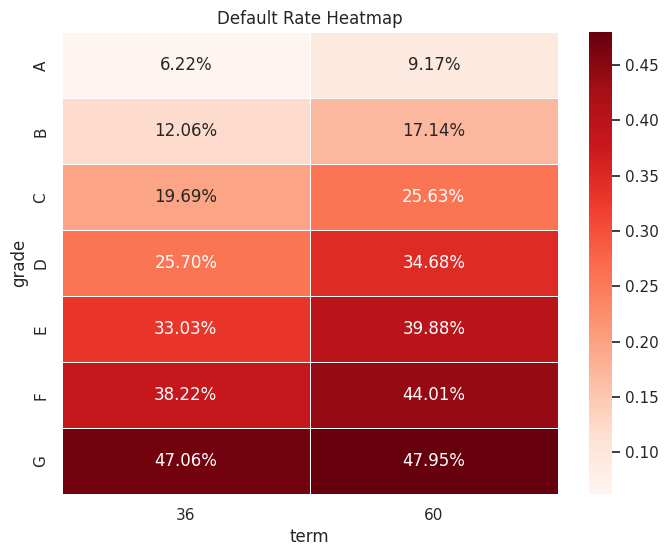

In [22]:
df["default_flag"] = (df["loan_status"] == "Charged Off").astype(int)

heatmap_data = df.pivot_table(
    values="default_flag",
    index="grade",
    columns="term",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2%",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Default Rate Heatmap")

plt.show()

The heatmap visualizes default rates across combinations of credit grade and loan term.

Higher default rates are observed among borrowers with lower credit grades and longer loan terms.

This indicates that the combination of weaker credit quality and longer repayment periods significantly increases default risk within the lending portfolio.

## Risk Segmentation

Borrowers are segmented based on **Debt-to-Income ratio levels**.

DTI is a critical affordability metric used by financial institutions to evaluate borrower repayment capacity.

This segmentation helps identify whether **higher leverage correlates with increased default risk**.

/tmp/ipykernel_198/3289012658.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_segment = df.groupby("dti_segment")["default_flag"].mean()


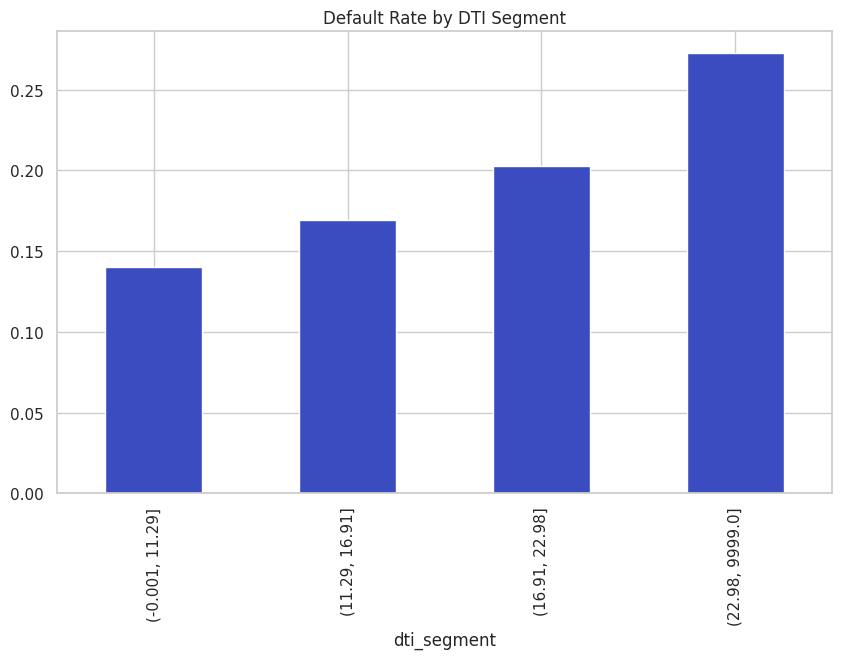

In [23]:
df["dti_segment"] = pd.qcut(df["dti"], 4)

risk_segment = df.groupby("dti_segment")["default_flag"].mean()

risk_segment.plot(
    kind="bar",
    colormap="coolwarm"
)

plt.title("Default Rate by DTI Segment")

plt.show()

The analysis shows a clear upward trend in default rates as Debt-to-Income ratios increase.

Borrowers in higher DTI segments demonstrate significantly higher default probabilities compared to those with lower leverage levels.

This result further confirms that borrower financial leverage plays a critical role in determining repayment behavior.

## Borrower Risk Profile

This section summarizes the financial profile of borrowers based on loan outcomes.

Key indicators analyzed:

• Income level  
• Debt-to-Income ratio  
• Credit utilization  
• Loan size

This comparison provides insight into **typical characteristics of higher-risk borrowers**.

In [24]:
risk_profile = df.groupby("loan_status")[[
    "annual_inc",
    "dti",
    "revol_util",
    "loan_amnt"
]].mean()

risk_profile

,annual_inc,dti,revol_util,loan_amnt
loan_status,,,,
2015-04-01 00:00:00,64000.000000,16.910000,9492.000000,25000.000000
Charged Off,67534.246743,19.656752,58.007159,15125.948018
Fully Paid,75829.790620,16.824652,53.169981,13866.808845
Unknown,64000.000000,16.910000,54.800000,15146.022727


## Loan Purpose Analysis

Loan purpose indicates the primary reason borrowers seek financing.

Analyzing loan purpose distribution helps identify:

• Major credit demand segments  
• Potential risk concentrations by loan category

/tmp/ipykernel_198/1601930402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


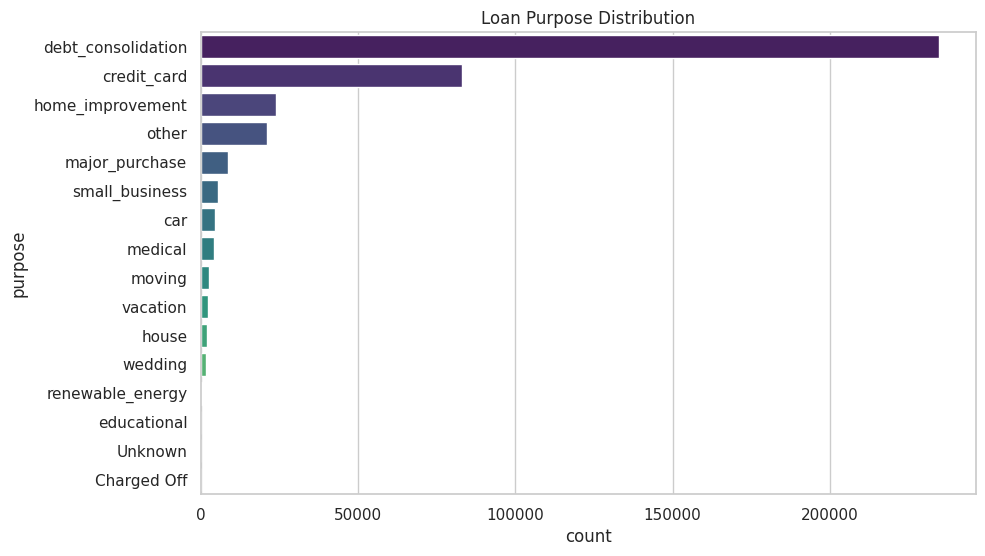

In [25]:
plt.figure()

sns.countplot(
    y="purpose",
    data=df,
    order=df["purpose"].value_counts().index,
    palette="viridis"
)

plt.title("Loan Purpose Distribution")

plt.show()

## Portfolio Risk Overview

To conclude the EDA section, we summarize key portfolio indicators that are typically monitored by credit risk teams:

• Average loan size  
• Average borrower income  
• Average Debt-to-Income ratio  
• Overall portfolio default rate

These metrics provide a simplified **portfolio monitoring dashboard**.

In [26]:
portfolio_summary = {
    "Average Loan Amount": df["loan_amnt"].mean(),
    "Average Borrower Income": df["annual_inc"].mean(),
    "Average DTI": df["dti"].mean(),
    "Portfolio Default Rate": df["default_flag"].mean()
}

portfolio_summary

{'Average Loan Amount': np.float64(14113.898540258415),
 'Average Borrower Income': np.float64(74201.6753322863),
 'Average DTI': np.float64(17.380041789868923),
 'Portfolio Default Rate': np.float64(0.19610180062571175)}

# **Feature Engineering**

Feature engineering transforms raw variables into meaningful predictors that better capture borrower risk behavior.

In credit risk modeling, engineered features are often more predictive than raw variables because they represent **borrower financial stability, leverage level, and exposure risk**.

This section constructs several domain-informed variables commonly used in financial risk analytics:

• Income segmentation  
• Debt-to-income risk indicators  
• Credit utilization risk levels  
• Loan size exposure categories  
• Employment stability score  

These engineered features will later be used in **credit risk modeling**.

## Income Segmentation

Borrower income is segmented into groups to capture differences in financial capacity.

Segmenting income helps models detect **non-linear risk patterns** across income levels.

In [27]:
df["income_bucket"] = pd.qcut(
    df["annual_inc"],
    q=5,
    labels=[
        "Very Low Income",
        "Low Income",
        "Middle Income",
        "High Income",
        "Very High Income"
    ]
)

df["income_bucket"].value_counts()

,count
income_bucket,
Very Low Income,83359
Middle Income,81567
Very High Income,79128
High Income,76868
Low Income,75107


## Debt-to-Income Risk Flag

The Debt-to-Income (DTI) ratio measures the borrower's financial leverage.

Higher DTI levels indicate that a larger portion of income is allocated to debt repayment, increasing the probability of default.

Borrowers are classified into risk categories based on DTI levels.

In [28]:
df["dti_risk_flag"] = pd.cut(
    df["dti"],
    bins=[0,10,20,35,100],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
)

df["dti_risk_flag"].value_counts()

,count
dti_risk_flag,
Moderate Risk,172820
High Risk,138252
Low Risk,78751
Very High Risk,5885


## Credit Utilization Risk

Credit utilization reflects how much of the available revolving credit is currently used.

High utilization often indicates financial stress and is strongly associated with higher default probability.

In [29]:
df["credit_utilization_risk"] = pd.cut(
    df["revol_util"],
    bins=[0,30,60,90,200],
    labels=[
        "Low Utilization",
        "Moderate Utilization",
        "High Utilization",
        "Critical Utilization"
    ]
)

df["credit_utilization_risk"].value_counts()

,count
credit_utilization_risk,
Moderate Utilization,153691
High Utilization,142311
Low Utilization,71850
Critical Utilization,25952


## Loan Size Category

Loan size represents exposure risk from the lender’s perspective.

Larger loans increase potential financial loss in the event of default.

In [30]:
df["loan_size_category"] = pd.qcut(
    df["loan_amnt"],
    q=4,
    labels=[
        "Small Loan",
        "Medium Loan",
        "Large Loan",
        "Very Large Loan"
    ]
)

df["loan_size_category"].value_counts()

,count
loan_size_category,
Small Loan,112277
Large Loan,111020
Medium Loan,91964
Very Large Loan,80768


## Employment Stability Score

Employment length provides insight into borrower income stability.

Borrowers with longer employment history generally demonstrate stronger repayment reliability.

In [31]:
df["emp_length"].unique()

array(['< 1 year', '10+ years', '4 years', '1 year', '3 years', nan,
       '6 years', '2 years', '7 years', '8 years', '5 years', '9 years',
       'Technology Implementation Specialist '], dtype=object)

In [32]:
emp_map = {
    "< 1 year":0.5,
    "1 year":1,
    "2 years":2,
    "3 years":3,
    "4 years":4,
    "5 years":5,
    "6 years":6,
    "7 years":7,
    "8 years":8,
    "9 years":9,
    "10+ years":10
}

df["employment_score"] = df["emp_length"].map(emp_map)

## Final Feature Set

After feature engineering, the dataset now includes several additional predictors that capture borrower risk patterns.

These features will be used in the **credit risk modeling stage**.

In [33]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'loan_status', 'purpose', 'dti', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
       'default_flag', 'dti_segment', 'income_bucket', 'dti_risk_flag',
       'credit_utilization_risk', 'loan_size_category', 'employment_score'],
      dtype='object')

In [34]:
engineered_features = [
    "income_bucket",
    "dti_risk_flag",
    "credit_utilization_risk",
    "loan_size_category",
    "employment_score"
]

engineered_features

['income_bucket',
 'dti_risk_flag',
 'credit_utilization_risk',
 'loan_size_category',
 'employment_score']

# **Credit Risk Modeling**

This section builds predictive models to estimate the probability of borrower default.

Two models are implemented:

• Logistic Regression (baseline credit risk model)  
• XGBoost (advanced machine learning model)

Logistic regression is widely used in traditional credit scoring systems due to its interpretability, while XGBoost is often applied in modern fintech environments due to its strong predictive performance.

The objective is to predict the **probability of loan default** based on borrower characteristics and engineered risk features.

## Feature Selection

We select relevant financial and engineered features that capture borrower risk behavior.

The target variable is:

default_flag  
(1 = default, 0 = fully paid)

In [35]:
features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "revol_util",
    "open_acc",
    "total_acc",
    "employment_score"
]

X = df[features]
y = df["default_flag"]

## Feature Encoding

Machine learning algorithms require numerical input.

Categorical variables are converted using **One-Hot Encoding**, which creates binary indicator variables for each category.

In [36]:
categorical_features = [
    "income_bucket",
    "dti_risk_flag",
    "credit_utilization_risk",
    "loan_size_category"
]

X = pd.concat([
    X,
    pd.get_dummies(df[categorical_features], drop_first=True)
], axis=1)

## Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

Standard practice uses:

• 80% training data  
• 20% testing data

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Logistic Regression Model

Logistic regression is the traditional model used in credit scoring.

It estimates the **probability of default** based on borrower characteristics.

In [38]:
X = X.fillna(X.median())

In [39]:
X.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
annual_inc,0
dti,0
revol_util,0
open_acc,0
total_acc,0
employment_score,0


In [40]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

In [41]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [46]:
y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

## XGBoost Model

XGBoost is a gradient boosting algorithm widely used in modern credit risk modeling.

It often outperforms traditional models due to its ability to capture **nonlinear relationships and feature interactions**.

In [47]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [48]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

## Model Evaluation

Model performance is evaluated using:

• ROC Curve  
• AUC Score  

These metrics measure the model’s ability to **distinguish between defaulted and non-defaulted loans**.

In [50]:
from sklearn.metrics import roc_curve, roc_auc_score

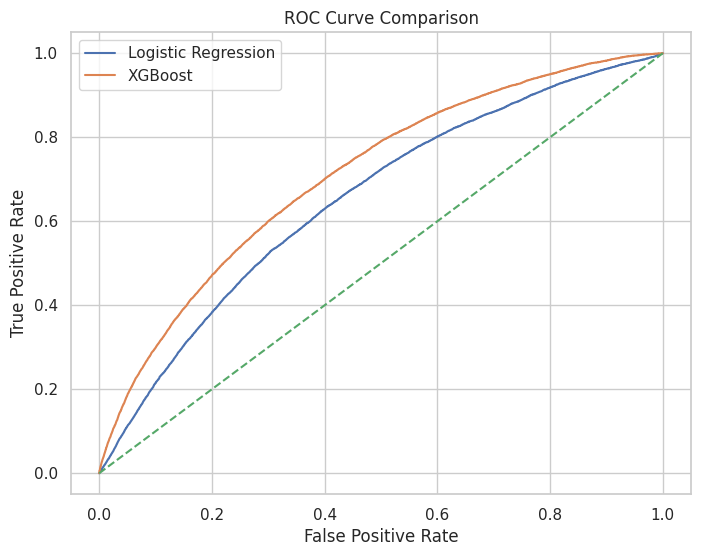

In [51]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

The ROC curve comparison shows that the XGBoost model outperforms the baseline Logistic Regression model in predicting borrower default.

The Logistic Regression model achieved an AUC score of approximately 0.65, while the XGBoost model reached an AUC of approximately 0.71.

This improvement suggests that the machine learning model captures nonlinear relationships and feature interactions more effectively, resulting in better predictive performance.

In [52]:
auc_log = roc_auc_score(y_test, y_prob_log)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Logistic Regression AUC:", auc_log)
print("XGBoost AUC:", auc_xgb)

Logistic Regression AUC: 0.6526605792295841
XGBoost AUC: 0.7097634414251042


## Feature Importance

Feature importance helps identify which variables contribute most to predicting borrower default.

This provides insights into **key risk drivers in the lending portfolio**.

In [53]:
feature_names = X.columns
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
)

importance.sort_values(ascending=False).head(10)

,0
int_rate,0.267156
term,0.225743
dti_risk_flag_High Risk,0.076538
dti_risk_flag_Very High Risk,0.069695
dti,0.048625
income_bucket_Very High Income,0.048061
annual_inc,0.040024
income_bucket_High Income,0.027141
loan_amnt,0.020283
credit_utilization_risk_Critical Utilization,0.020200


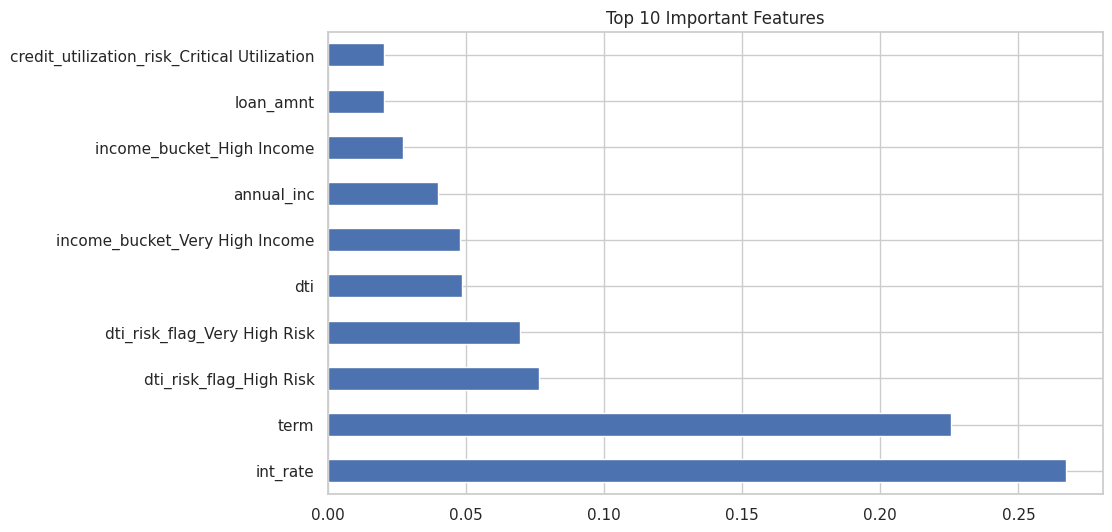

In [54]:
importance.sort_values(ascending=False).head(10).plot(
    kind="barh"
)

plt.title("Top 10 Important Features")

plt.show()

Feature importance analysis reveals that interest rate, loan term, debt-to-income ratio, borrower income, and credit utilization are among the most influential predictors of borrower default.

These variables represent key aspects of borrower financial behavior and lending conditions.

The results align with established credit risk theory, where borrower leverage, income stability, and borrowing costs significantly influence repayment outcomes.

## Risk Score Generation

The predicted probability of default can be transformed into a **risk score**.

Higher probabilities indicate higher credit risk.

In [55]:
default_prob = log_model.predict_proba(X_test)[:,1]

In [56]:
test_results = pd.DataFrame()

In [57]:
test_results = pd.DataFrame({
    "actual_default": y_test,
    "predicted_default_probability": default_prob
})

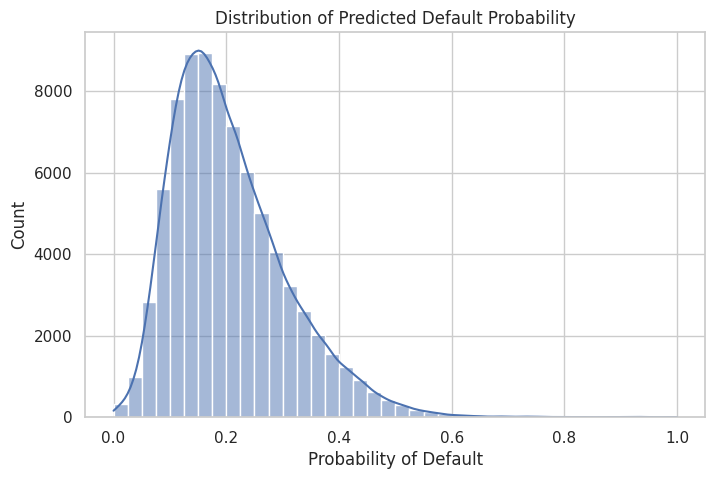

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    test_results["predicted_default_probability"],
    bins=40,
    kde=True
)

plt.title("Distribution of Predicted Default Probability")

plt.xlabel("Probability of Default")

plt.show()

# **Advanced Model Evaluation**

To evaluate the performance of the credit risk model, several evaluation metrics commonly used in financial institutions are applied.

These include:

• Confusion Matrix  
• Precision, Recall, and F1 Score  
• ROC Curve and AUC  
• Kolmogorov–Smirnov (KS) Statistic  

These metrics help assess how well the model can distinguish between **good borrowers and potential defaulters**.

<Figure size 600x500 with 0 Axes>

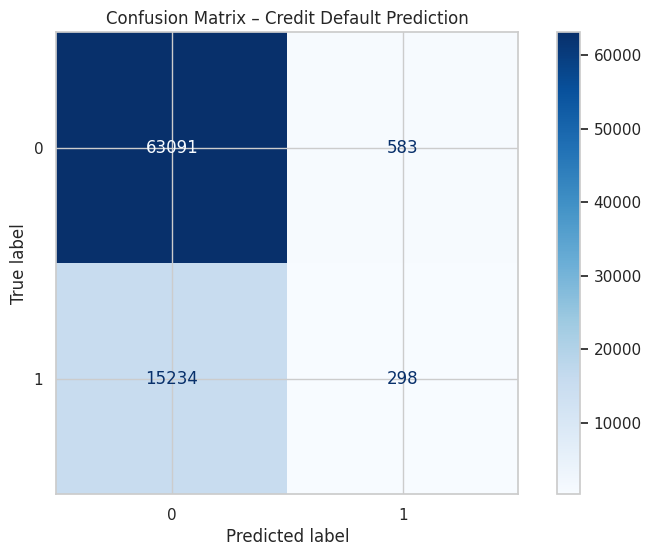

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, log_model.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Credit Default Prediction")
plt.show()

The confusion matrix summarizes the prediction results:

• True Negatives – correctly predicted non-default borrowers  
• True Positives – correctly predicted default borrowers  
• False Positives – borrowers predicted as default but actually paid  
• False Negatives – borrowers predicted safe but actually defaulted  

In credit risk modeling, minimizing **false negatives** is particularly important, as these represent risky borrowers incorrectly approved.

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89     63674
           1       0.34      0.02      0.04     15532

    accuracy                           0.80     79206
   macro avg       0.57      0.51      0.46     79206
weighted avg       0.71      0.80      0.72     79206



Key evaluation metrics:

Precision  
Measures how many predicted defaulters actually default.

Recall  
Measures how many actual defaulters were correctly identified.

F1 Score  
Balances precision and recall.

In credit risk applications, **recall is particularly important**, as failing to identify risky borrowers may lead to financial losses.

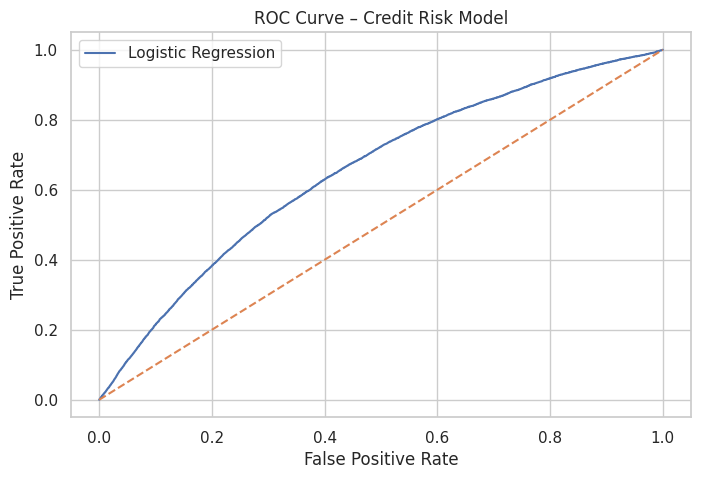

AUC Score: 0.6526605792295841


In [61]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve – Credit Risk Model")

plt.legend()

plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

In [62]:
from scipy.stats import ks_2samp

good = y_prob[y_test==0]
bad = y_prob[y_test==1]

ks_stat = ks_2samp(good, bad)

print("KS Statistic:", ks_stat.statistic)

KS Statistic: 0.23021840923204373


The Kolmogorov–Smirnov (KS) statistic measures the separation between predicted probabilities of good and bad borrowers.

Typical interpretation:

KS < 0.2  → weak model  
KS 0.2–0.4 → acceptable model  
KS > 0.4 → strong risk separation

Financial institutions commonly use KS statistics when evaluating credit scoring models.

# **Business Insights**

Beyond model performance, the analysis provides insights into borrower risk characteristics and potential lending strategies.

Key questions addressed:

• Which borrower segments present the highest default risk?
• How can lenders optimize loan approval strategies?
• What borrower characteristics signal elevated credit risk?

In [63]:
test_results["risk_segment"] = pd.qcut(
    test_results["predicted_default_probability"],
    5,
    labels=["Very Low","Low","Medium","High","Very High"]
)

risk_summary = test_results.groupby("risk_segment").agg({
    "predicted_default_probability":"mean",
    "actual_default":"mean"
})

risk_summary

/tmp/ipykernel_198/267747970.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = test_results.groupby("risk_segment").agg({


,predicted_default_probability,actual_default
risk_segment,,
Very Low,0.087939,0.093738
Low,0.142379,0.130295
Medium,0.188008,0.186731
High,0.245935,0.243671
Very High,0.367027,0.326053


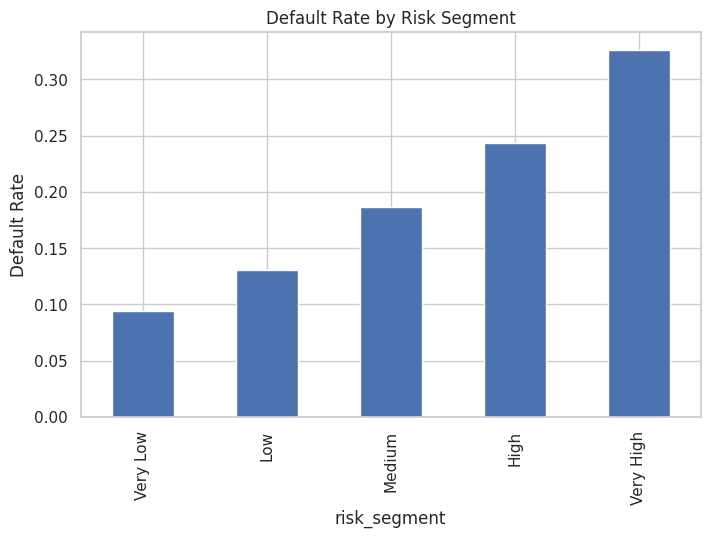

In [64]:
risk_summary["actual_default"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Default Rate by Risk Segment")

plt.ylabel("Default Rate")

plt.show()

Borrowers classified in the **High** and **Very High** risk segments show significantly higher default rates.

This segmentation allows lenders to implement differentiated lending strategies based on borrower risk levels.

Based on predicted default probabilities, lenders can define approval thresholds.

Example strategy:

Very Low Risk → Automatic approval  
Low Risk → Standard approval  
Medium Risk → Manual review  
High Risk → Require additional verification  
Very High Risk → Loan rejection

Key risk indicators identified by the model include:

• High debt-to-income ratio (DTI)  
• High revolving credit utilization  
• Lower income levels  
• Short employment history  

Borrowers with these characteristics may require stricter credit evaluation procedures.

# **Executive Conclusion**

This project developed an end-to-end credit risk modeling pipeline using Lending Club loan data.

The analysis included:

• Data cleaning and preprocessing  
• Exploratory data analysis  
• Feature engineering  
• Credit risk modeling using logistic regression  
• Model evaluation using ROC, AUC, and KS statistics  

The model successfully identifies high-risk borrowers and provides actionable insights for credit risk management.

Key outcomes:

• Effective borrower risk segmentation  
• Identification of key credit risk drivers  
• Practical approval strategies for lenders  

This type of analytical framework is commonly used by fintech companies and financial institutions to improve lending decisions and reduce default risk.

# **Probability of Default (PD) Risk Scoring**

Financial institutions often translate predicted default probabilities into
risk scores to simplify lending decisions.

Borrowers are categorized into different risk levels based on predicted
probability of default.

In [65]:
test_results["risk_score"] = (1 - test_results["predicted_default_probability"]) * 100

test_results.head()

,actual_default,predicted_default_probability,risk_segment,risk_score
16946,0,0.171810,Medium,82.818964
119425,0,0.290972,Very High,70.902778
234411,1,0.261323,High,73.867672
133468,0,0.045293,Very Low,95.470746
172320,0,0.193396,Medium,80.660441


In [66]:
test_results["credit_grade"] = pd.cut(
    test_results["risk_score"],
    bins=[0,20,40,60,80,100],
    labels=["Very Risky","High Risk","Medium Risk","Low Risk","Very Safe"]
)

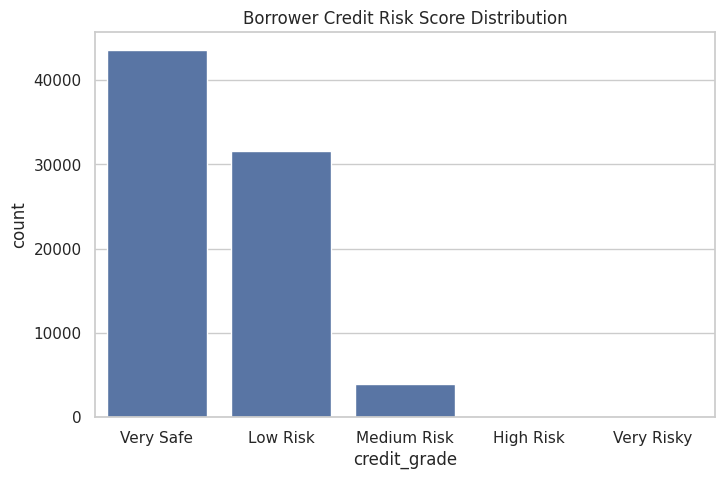

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="credit_grade",
    data=test_results,
    order=["Very Safe","Low Risk","Medium Risk","High Risk","Very Risky"]
)

plt.title("Borrower Credit Risk Score Distribution")

plt.show()

Borrowers classified as "High Risk" and "Very Risky" have significantly
higher predicted default probabilities.

This scoring system can be used by lenders to automate approval decisions
and prioritize risk monitoring.

In [68]:
!pip install shap

In [69]:
import shap

explainer = shap.Explainer(log_model, X_train)

shap_values = explainer(X_test)

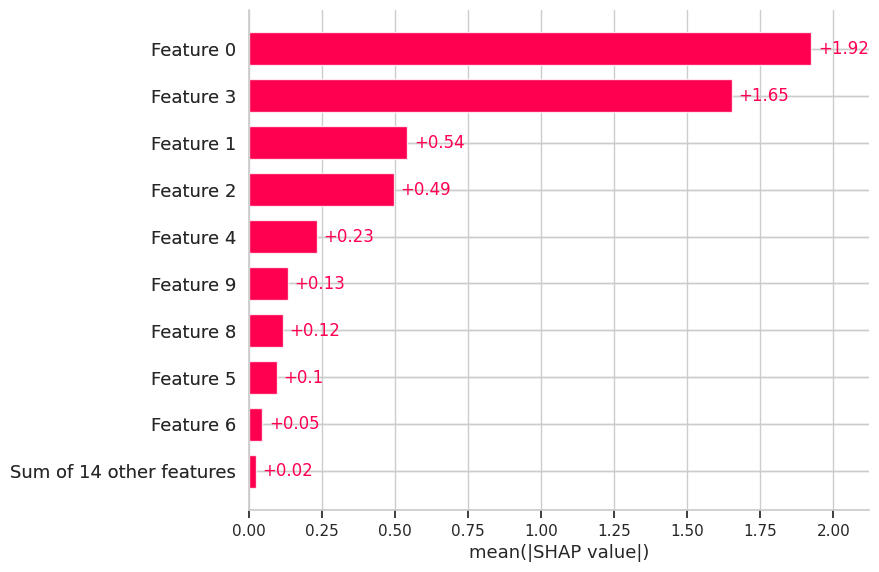

In [70]:
shap.plots.bar(shap_values)

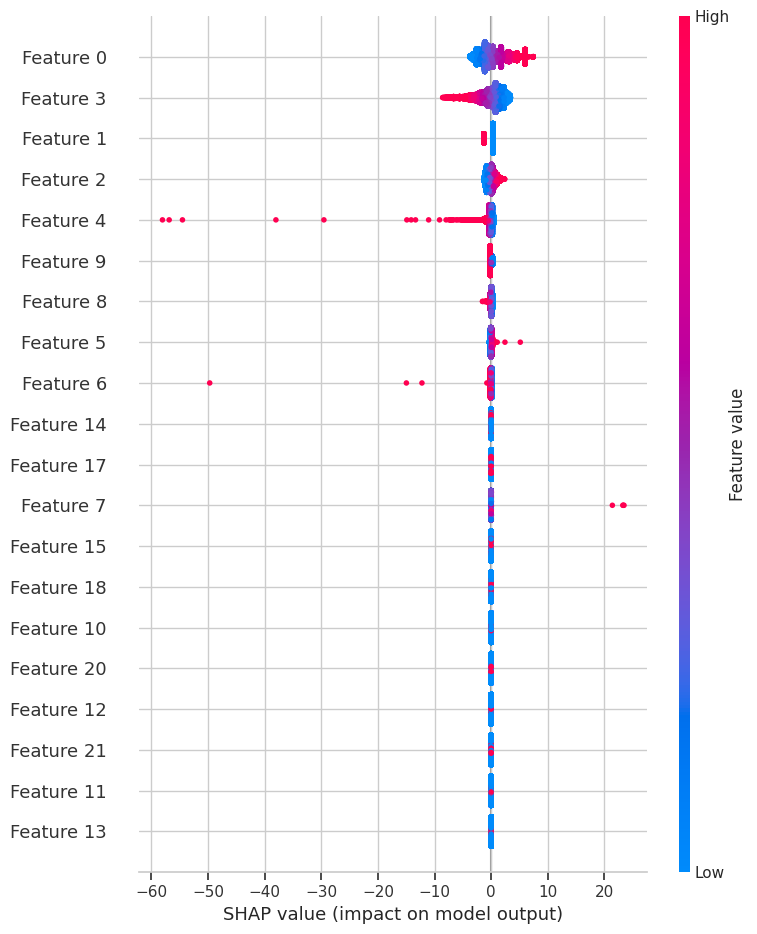

In [71]:
shap.summary_plot(shap_values, X_test)

# **Loan Portfolio Risk Dashboard**

This section summarizes the overall risk profile of the lending portfolio,
including borrower segmentation and default risk distribution.

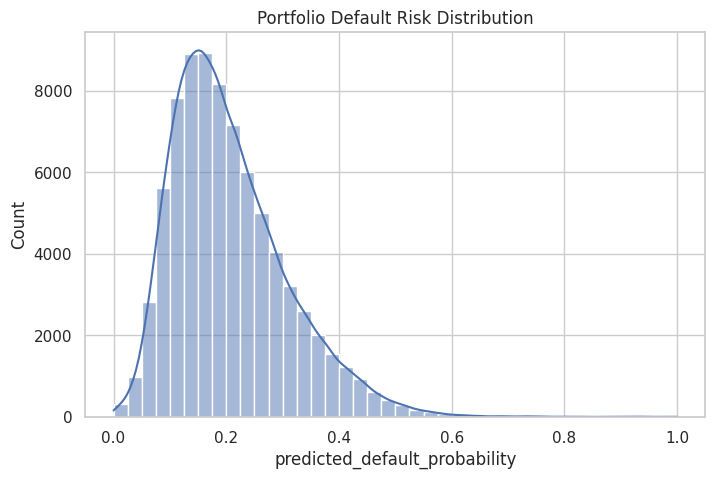

In [72]:
plt.figure(figsize=(8,5))

sns.histplot(
    test_results["predicted_default_probability"],
    bins=40,
    kde=True
)

plt.title("Portfolio Default Risk Distribution")

plt.show()

/tmp/ipykernel_198/28618456.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_default = test_results.groupby("risk_segment")["actual_default"].mean()


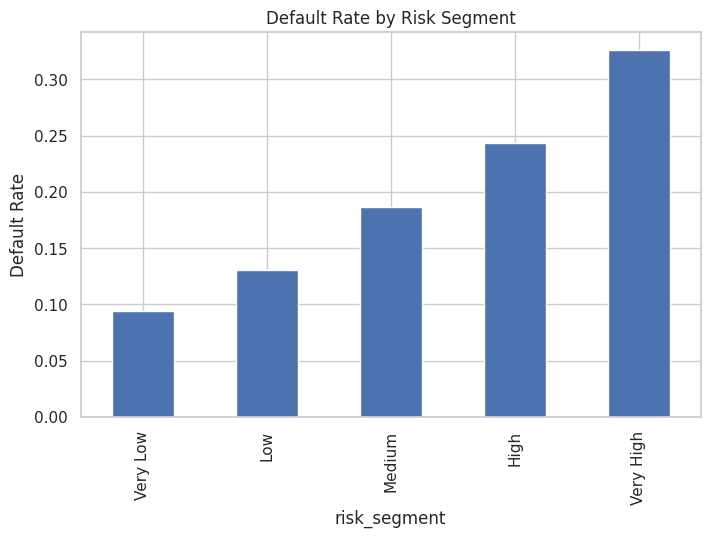

In [73]:
segment_default = test_results.groupby("risk_segment")["actual_default"].mean()

segment_default.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Default Rate by Risk Segment")

plt.ylabel("Default Rate")

plt.show()

Borrowers were segmented into five risk groups based on predicted probability of default.

The observed default rate increases consistently from the Very Low risk segment to the Very High risk segment, indicating that the model successfully separates borrowers based on credit risk levels.

Such segmentation allows lenders to implement differentiated credit strategies, including automated approval for low-risk borrowers and stricter screening for high-risk applicants.

In [74]:
portfolio_summary = test_results.groupby("risk_segment").agg({
    "predicted_default_probability":"mean",
    "actual_default":"mean",
    "risk_score":"mean"
})

portfolio_summary

/tmp/ipykernel_198/1253087673.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  portfolio_summary = test_results.groupby("risk_segment").agg({


,predicted_default_probability,actual_default,risk_score
risk_segment,,,
Very Low,0.087939,0.093738,91.206122
Low,0.142379,0.130295,85.762125
Medium,0.188008,0.186731,81.199242
High,0.245935,0.243671,75.406486
Very High,0.367027,0.326053,63.297264


# **Expected Loss Simulation (Bank Risk Framework)**

Financial institutions estimate credit losses using the Expected Loss framework:

Expected Loss (EL) = PD × LGD × EAD

Where:

PD (Probability of Default)
Probability that the borrower will default.

LGD (Loss Given Default)
Proportion of the loan that will be lost if default occurs.

EAD (Exposure at Default)
Outstanding loan exposure at the time of default.

This framework is widely used in banking risk management and regulatory capital calculations.

LGD unsecured loan ≈ 40%–60%

In [75]:
test_results["EAD"] = df.loc[y_test.index, "loan_amnt"]

In [76]:
test_results["LGD"] = 0.6

In [77]:
test_results["PD"] = test_results["predicted_default_probability"]

In [78]:
test_results["expected_loss"] = (
    test_results["PD"]
    * test_results["LGD"]
    * test_results["EAD"]
)

test_results.head()

,actual_default,predicted_default_probability,risk_segment,risk_score,credit_grade,EAD,LGD,PD,expected_loss
16946,0,0.171810,Medium,82.818964,Very Safe,10000,0.6,0.171810,1030.862172
119425,0,0.290972,Very High,70.902778,Low Risk,15250,0.6,0.290972,2662.395822
234411,1,0.261323,High,73.867672,Low Risk,27000,0.6,0.261323,4233.437137
133468,0,0.045293,Very Low,95.470746,Very Safe,16000,0.6,0.045293,434.808337
172320,0,0.193396,Medium,80.660441,Very Safe,20000,0.6,0.193396,2320.747045


In [79]:
portfolio_el = test_results["expected_loss"].sum()

print("Total Expected Loss:", portfolio_el)

Total Expected Loss: 140799742.8670429


In [80]:
test_results["expected_loss"].mean()

np.float64(1777.639861463057)

In [81]:
el_segment = test_results.groupby("risk_segment").agg({
    "expected_loss":"mean",
    "PD":"mean",
    "EAD":"mean"
})

el_segment

/tmp/ipykernel_198/2360269551.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  el_segment = test_results.groupby("risk_segment").agg({


,expected_loss,PD,EAD
risk_segment,,,
Very Low,759.544143,0.087939,14627.136725
Low,1199.385059,0.142379,14055.747743
Medium,1510.955279,0.188008,13412.429771
High,1896.520560,0.245935,12840.631905
Very High,3521.858536,0.367027,15666.359447


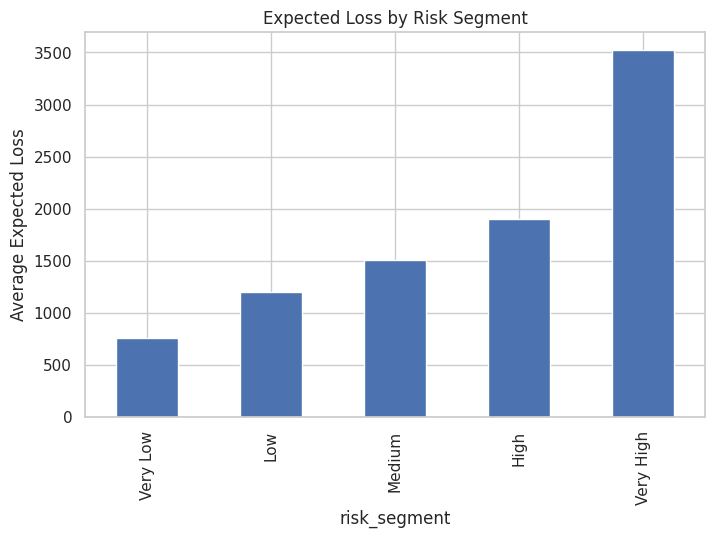

In [82]:
el_segment["expected_loss"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Expected Loss by Risk Segment")

plt.ylabel("Average Expected Loss")

plt.show()

Expected Loss was calculated using the standard credit risk framework:

Expected Loss = Probability of Default × Loss Given Default × Exposure at Default.

Assuming a Loss Given Default (LGD) of 60%, the estimated total expected loss for the portfolio is approximately 140.8 million dollars, with an average expected loss of around 1,777 dollars per loan.

Borrowers in the High and Very High risk segments contribute disproportionately to the portfolio's expected losses, highlighting the importance of risk-based lending strategies.